# TEMPO Tutorial 1: 
## Rabi Oscillations in a 2-level System

### Import packages

In [1]:
import sys

# Add TEMPO path to searchable directory list
dirpath_pers = "/Users/jjoon/Documents/GitHub/TEMPO/"

if dirpath_pers not in sys.path:
    sys.path.insert(0, dirpath_pers)

In [2]:
from qutip import *
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt
import scipy.signal as scs

from multiprocess import Pool

In [3]:
from tempo.hamiltonian import Hamiltonian
from tempo.pulse_recipe import Pulse_recipe
from tempo.evolver import Evolver
from tempo.pulse_sequence import Pulse_sequence
from tempo.pulse import Pulse

## Step 1: Create Pulse Recipe

In [4]:
# define the time-dependent pulse type of functional form:
# A*cos(omega*(t+offset)+phase)
# function must have inputs t, args
def func_X(t, args):
    return args['AMP']*np.cos(2*np.pi*args['FREQ']*t)

# operator to be multiplied by function output
H_X = 2 * np.pi * sigmax()

# parameter names for pulse recipe
keys_X = ['AMP', 'FREQ']

# create the pulsetype object with the operator, parameter names, and function
# we do not input numerical values yet; this pulsetype is a blueprint for any ACD pulse
# values will come later
recipe_X = Pulse_recipe(Hamiltonian(H_X), keys_X, func_X)

## Step 2: Create Pulse(s)

In [5]:
# parameters for static Hamiltonian 
E0 = 1000
pars_Hsz = {'coeff': -2*np.pi, 'E': E0}
ops_Hsz = {'SZ': sigmaz()}

# define function for static Hamiltonian
def f_Hsz(ops, pars):
    sz = ops['SZ']
    c = pars['coeff']
    E = pars['E']

    return c * E * sz

In [6]:
# create static Hamiltonian
Hs = Hamiltonian(ops_Hsz, pars_Hsz, f_Hsz)

# extract the static Hamiltonian operator
Hs_op = Hs.H

# calculate eigenenergies
eig_energies = Hs_op.eigenenergies()/2/np.pi

# resonance frequency of transition
frq_trans =  max(eig_energies) - min(eig_energies)

In [7]:
# pulse start time
t0 = .1

# pulse duration
tpulse = .3

# amplitude of oscillating field
amp = 12

# specify parameter values for individual pulse
par_values = {'AMP': amp, 'FREQ': frq_trans}

# create individual pulse
pulseX = Pulse(recipe_X, 
               start_time = t0, 
               duration = tpulse, 
               coeff_params = par_values)


## Step 3: Create Pulse Sequence

In [8]:
# Define pulse sequence object instance with static Hamiltonian as input
# qutip Qobjs are also allowed as input to Hstat
pseq = Pulse_sequence(Hstat = Hs)

# Add pulse to sequence
pseq.add_pulse(pulseX)

## Step 4: Evolve System in Time

In [9]:
# create array of evaluation times for output
Teval_start = 0
Teval_end = 2*tpulse
Npts_eval = 501
times_eval = np.linspace(Teval_start, Teval_end, Npts_eval)

# Define 2-level system initial state
state_init = basis(2,0) 

# initialize evolver objects (no difference at this point)
ev = Evolver(state_init, times_eval, pseq)

# Run evaluation
result = ev.evolve(method = 'regular')


/Users/jjoon/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


## Plot

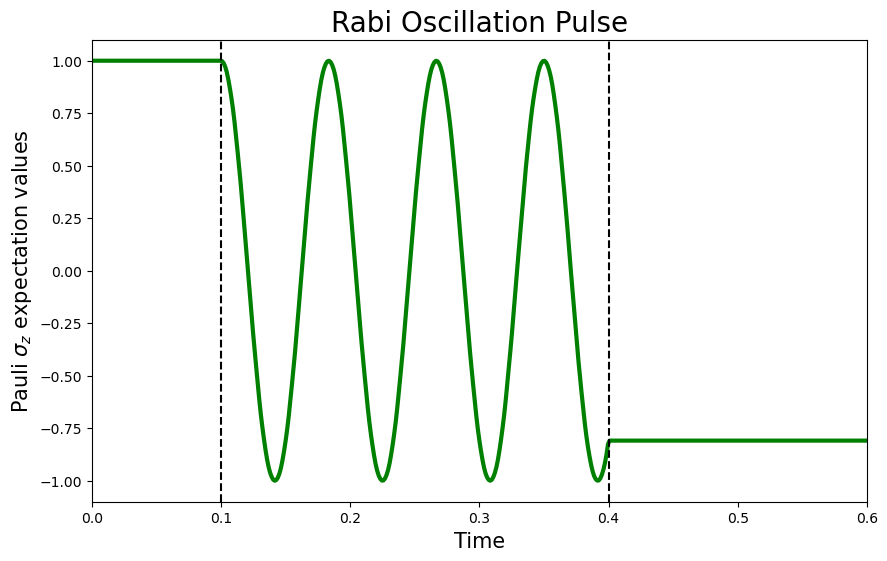

In [10]:
# Evaluate expectation values of Pauli sigma_z operator
expectations_Z = expect(sigmaz(), result.states)

# Create figure
plt.figure(figsize=(10,6))
plt.plot(times_eval, expectations_Z, lw=3, c="green")

# vertical lines to denote start and end time of pulse
vert_props = dict(color="black", linestyle="--")
plt.axvline(pulseX.start_time, **vert_props)
plt.axvline(pulseX.end_time, **vert_props)

# labels
title_font = dict(fontsize=20, weight="normal")
labels_font = dict(fontsize=15, weight="light")
plt.title("Rabi Oscillation Pulse", fontdict=title_font)
plt.xlabel("Time", fontdict=labels_font)
plt.ylabel("Pauli $\sigma_z$ expectation values", fontdict=labels_font)

plt.xlim(min(times_eval), max(times_eval))
plt.show()